# Experiment of Algorithm Selection Varying Algorithm Similarity

In this notebook, we compare the selection accuracy of AVG and MID using A/B testing data (and IPS using offline data) varying the algorithm similarity.

In [1]:
import os
import contextlib
import warnings

import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from scipy import stats

from dataset import KuaiRecDataset
from estimation import run_experiment
from utils import evaluate_performance

warnings.filterwarnings('ignore')

## Experiment

In [2]:
# experiment configuration
n_sims = 10000 # number of simulation runs
n0_data = 500 # sample size logged from policy 0 (algorithm A)
n1_data = 500 # sample size logged from policy 1 (algorithm B)
n_actions = 30 # number of actions
reward_std = 5.0 # level of noise on the reward
reward_type = "continuous" # binary or continuous

# policy params
# - policy_kind: the kind of conditioned action distribution
# - mu_rate: the peak position rate of the action distribution
# - sigma: the length of tail
policy_0_params = {"policy_kind": "sorted_normal", "mu_rate": 0.0, "sigma": 8.0}
policy_1_params_list = [
    {"policy_kind": "sorted_normal", "mu_rate": 0.0, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.1, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.2, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.3, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.4, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.5, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.6, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.7, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.8, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 0.9, "sigma": 8.0},
    {"policy_kind": "sorted_normal", "mu_rate": 1.0, "sigma": 8.0},
]

In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [4]:
def estimate(policy_0_params, policy_1_params):
    dataset = KuaiRecDataset(
        n_actions=n_actions,
        reward_std=reward_std,
        random_state=os.getpid()
    )

    true_value_of_0_policy   = dataset.calc_policy_value(policy_params=policy_0_params)
    true_value_of_1_policy   = dataset.calc_policy_value(policy_params=policy_1_params)
    true_value_of_mid_policy = dataset.calc_mid_policy_value(
        policy_0_params=policy_0_params, policy_1_params=policy_1_params
    )
    is_1_policy_better = np.int32(true_value_of_0_policy < true_value_of_1_policy)
    is_1_policy_better = is_1_policy_better - (1 - is_1_policy_better)

    estimated_pi_0_value_list     = []
    estimated_pi_1_value_list     = []
    estimated_pi_m_D_1_value_list = []
    estimated_pi_m_D_0_value_list = []
    estimated_comparison_list     = []
    estimated_p_value_list        = []

    for _ in range(n_sims):
        D_E_0 = dataset.generate_dataset(
            n_data=n0_data,
            logging_policy_params=policy_0_params,
            evaluation_policy_params=policy_1_params
        )
        D_E_1 = dataset.generate_dataset(
            n_data=n1_data,
            logging_policy_params=policy_1_params,
            evaluation_policy_params=policy_0_params
        )

        values_of_pi_1, values_of_pi_m_D_1, values_of_pi_m_D_0, values_of_pi_0, comparison, p_value = run_experiment([D_E_0, D_E_1])
        estimated_pi_1_value_list.append(values_of_pi_1)
        estimated_pi_m_D_1_value_list.append(values_of_pi_m_D_1)
        estimated_pi_m_D_0_value_list.append(values_of_pi_m_D_0)
        estimated_pi_0_value_list.append(values_of_pi_0)
        estimated_comparison_list.append(comparison)
        estimated_p_value_list.append(p_value)

    result_df = (
        pd.concat([
            pd.DataFrame(estimated_pi_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_0_value_list).stack(),
            pd.DataFrame(estimated_pi_0_value_list).stack(),
            pd.DataFrame(estimated_comparison_list).stack(),
            pd.DataFrame(estimated_p_value_list).stack(),
        ], axis=1)
        .reset_index(1)
        .rename(columns={
            "level_1": "est",
            0: "pi_1_value", 1: "pi_m_D_1_value", 2: "pi_m_D_0_value",
            3: "pi_0_value", 4: "selection", 5: "p_value"
        })
    )
    result_df["mu_rate_0"]       = policy_0_params["mu_rate"]
    result_df["mu_rate_1"]       = policy_1_params["mu_rate"]
    result_df["true_pi_0_value"] = true_value_of_0_policy
    result_df["true_pi_1_value"] = true_value_of_1_policy
    result_df["true_pi_m_value"] = true_value_of_mid_policy
    result_df["selection"]      *= is_1_policy_better
    result_df["selection"]       = result_df["selection"] == 1

    return result_df

In [5]:
with tqdm_joblib(tqdm(total=len(policy_1_params_list))):
    result_df_list = Parallel(n_jobs=-1, verbose=0)(
        [delayed(estimate)(policy_0_params, policy_1_params) for policy_1_params in policy_1_params_list]
    )

result_df = pd.concat(result_df_list).reset_index(level=0)
result_df

  0%|          | 0/11 [00:00<?, ?it/s]/Users/hdymacuser/workspace/kdd2026-mid/notebooks/utils.py:71: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = np.abs(mean_a - mean_b) / se
/Users/hdymacuser/workspace/kdd2026-mid/notebooks/utils.py:75: RuntimeWarning: invalid value encountered in scalar divide
  df = df_num / df_den
100%|██████████| 11/11 [01:48<00:00,  9.82s/it]


,index,est,pi_1_value,pi_m_D_1_value,pi_m_D_0_value,pi_0_value,selection,p_value,mu_rate_0,mu_rate_1,true_pi_0_value,true_pi_1_value,true_pi_m_value
0,0,AVG,0.211752,0.000000,0.000000,0.388538,True,5.717427e-01,0.0,0.0,0.540052,0.540052,0.540052
1,0,IPS,0.388538,0.000000,0.000000,0.388538,True,1.000000e+00,0.0,0.0,0.540052,0.540052,0.540052
2,0,AVG_IPS,0.211752,0.211752,0.388538,0.388538,True,NaN,0.0,0.0,0.540052,0.540052,0.540052
3,0,MIN,0.211752,0.211752,0.388538,0.388538,True,NaN,0.0,0.0,0.540052,0.540052,0.540052
4,0,MID,0.211752,0.211752,0.388538,0.388538,True,5.740121e-01,0.0,0.0,0.540052,0.540052,0.540052
...,...,...,...,...,...,...,...,...,...,...,...,...,...
549995,9999,AVG,1.356497,0.000000,0.000000,0.064625,True,3.899858e-05,0.0,1.0,0.540052,1.609833,0.171035
549996,9999,IPS,13.972087,0.000000,0.000000,0.064625,True,2.973609e-01,0.0,1.0,0.540052,1.609833,0.171035
549997,9999,AVG_IPS,1.356497,0.803878,7.018356,0.064625,True,2.598283e-01,0.0,1.0,0.540052,1.609833,0.171035
549998,9999,MIN,1.356497,0.039902,0.153604,0.064625,True,1.109636e-06,0.0,1.0,0.540052,1.609833,0.171035


## Analyze

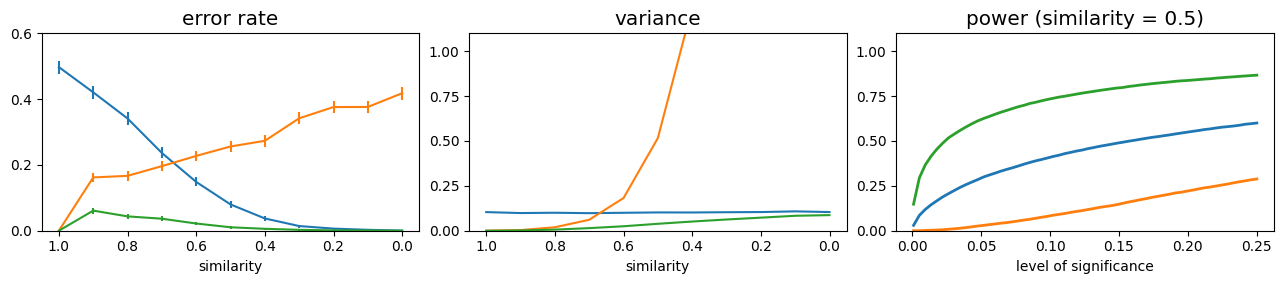

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
plt.rcParams["font.size"] = 12
for est_name in ["AVG", "IPS", "MID"]:
    mask_est = result_df["est"] == est_name
    result_dict = {
        "error rate": [],
        "error rate lower": [],
        "error rate upper": [],
        "error rate interval": [],
        "squared_bias": [],
        "variance": [],
        "MSE": [],
    }
    
    mu_rate_1_list = [params["mu_rate"] for params in policy_1_params_list]
    for mu_rate_1 in mu_rate_1_list:
        mask_mu_rate_1 = result_df["mu_rate_1"] == mu_rate_1
        mask = mask_est & mask_mu_rate_1
        result = result_df[mask].copy()
        performance = evaluate_performance(result)
        
        result["delta_value"] = result["pi_1_value"] - result["pi_m_D_1_value"] + result["pi_m_D_0_value"] - result["pi_0_value"]
        est_selection = result["delta_value"] > 0
        m, e, d = np.mean(est_selection), stats.sem(est_selection), len(est_selection) - 1
        interval = stats.t.interval(0.95, d, loc=m, scale=e)
        
        result_dict["error rate"].append(1.0-performance["accuracy"])
        result_dict["error rate lower"].append(1.0-interval[0])
        result_dict["error rate upper"].append(1.0-interval[1])
        result_dict["error rate interval"].append(interval[1]-interval[0])
        result_dict["squared_bias"].append(performance["squared_bias"])
        result_dict["variance"].append(performance["variance"])
        result_dict["MSE"].append(performance["MSE"])
    
    axes[0].errorbar(mu_rate_1_list, result_dict["error rate"], yerr=result_dict["error rate interval"], label=f"{est_name}")
    axes[0].set_ylim(0.0, 0.60)
    axes[0].set_xlabel("similarity")
    axes[0].set_title("error rate")
    
    axes[1].plot(mu_rate_1_list, result_dict["variance"], label=f"{est_name}")
    axes[1].set_xlabel("similarity")
    axes[1].set_title("variance")
    axes[1].set_ylim(0, 1.1)
    
    mask_mu_rate_1 = result_df["mu_rate_1"] == 0.5
    mask = mask_est & mask_mu_rate_1
    result = result_df[mask].copy()
    
    alpha_grid = np.linspace(0.001, 0.25, 60)
    power = np.array([(result["p_value"] < alpha).mean() for alpha in alpha_grid])
    axes[2].plot(alpha_grid, power, label=f'{est_name}', lw=2)
    axes[2].set_title(f"power (similarity = {0.5})")
    axes[2].set_xlabel("level of significance")
    axes[2].set_ylim(0, 1.1)

axes[0].set_xticklabels([1.2, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0])
axes[1].set_xticklabels([1.2, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0])

plt.tight_layout()
plt.show()